## Transformer-Style Pipeline (LSTM)
This section mirrors the Transformer notebook workflow, but uses an LSTM model.

In [1]:
# Imports and shared setup (same style as Transformer/CNN notebooks)
import numpy as np
import random
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error


def build_sequences_multivariate(df, feature_cols, target_col, window_size):
    values_x = df[feature_cols].values.astype(np.float32)
    values_y = df[target_col].values.astype(np.float32)
    x, y = [], []
    for i in range(len(df) - window_size):
        x.append(values_x[i:i + window_size])
        y.append(values_y[i + window_size])
    return np.array(x, dtype=np.float32), np.array(y, dtype=np.float32)


def select_input_features(df, target_col='SoH', require_core_signals=False):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    candidate_cols = [c for c in numeric_cols if c != target_col]

    core_aliases = {
        'voltage': ['voltage', 'volt', 'v_'],
        'current': ['current', 'curr', 'i_'],
        'temperature': ['temperature', 'temp', 't_']
    }

    core_found, missing_core = [], []
    for signal_name, aliases in core_aliases.items():
        matched = [c for c in candidate_cols if any(a in c.lower() for a in aliases)]
        if len(matched) == 0:
            missing_core.append(signal_name)
        else:
            core_found.extend(matched)

    if require_core_signals and len(missing_core) > 0:
        raise ValueError(f"Missing required core signals: {missing_core}")

    useful_aliases = ['cycle', 'resistance', 'ir', 'capacity', 'ccct', 'cvct', 'dqdv', 'energy', 'power']
    useful_cols = [
        c for c in candidate_cols
        if c not in core_found and any(a in c.lower() for a in useful_aliases)
    ]
    remaining_cols = [c for c in candidate_cols if c not in core_found and c not in useful_cols]
    feature_cols = core_found + useful_cols + remaining_cols
    return feature_cols, core_found, missing_core


def setup_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


def eval_loader_loss(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_all, targets_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb).squeeze(-1)
            loss = criterion(pred, yb)
            running_loss += loss.item() * xb.size(0)
            preds_all.append(pred.cpu().numpy())
            targets_all.append(yb.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    return avg_loss, np.concatenate(preds_all), np.concatenate(targets_all)


Battery_list = ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
Battery = np.load('datasets/CALCE/CALCE.npy', allow_pickle=True).item()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
setup_seed(42)
print(f'Using device: {device}')

Using device: cpu


In [2]:
# LSTM model definition (same input/output style)
class LSTM_SOHPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last)


# Single hold-out battery train/test with reserved future battery (same as Transformer)
window_size = 16
batch_size = 32
target_col = 'SoH'

test_battery_name = 'CS2_35'
future_battery_name = 'CS2_37'

common_numeric_cols = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

feature_cols, core_signal_cols, missing_core_signals = select_input_features(
    Battery[test_battery_name][common_numeric_cols],
    target_col=target_col,
    require_core_signals=False
)

train_batteries = [b for b in Battery_list if b != future_battery_name]

X_train_all, y_train_all = [], []
for b in train_batteries:
    df_bat = Battery[b][feature_cols + [target_col]].dropna().copy()
    X_tmp, y_tmp = build_sequences_multivariate(df_bat, feature_cols, target_col, window_size)
    X_train_all.append(X_tmp)
    y_train_all.append(y_tmp)
X_train_all = np.vstack(X_train_all)
y_train_all = np.hstack(y_train_all)

df_test = Battery[test_battery_name][feature_cols + [target_col]].dropna().copy()
X_test_raw, y_test_raw = build_sequences_multivariate(df_test, feature_cols, target_col, window_size)

df_future = Battery[future_battery_name][feature_cols + [target_col]].dropna().copy()
X_future_raw, y_future_raw = build_sequences_multivariate(df_future, feature_cols, target_col, window_size)

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
)

scaler_X_lstm = StandardScaler()
scaler_y_lstm = StandardScaler()

n_train, w_size, n_feat = X_train_raw.shape
X_train_lstm = scaler_X_lstm.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

n_val = X_val_raw.shape[0]
X_val_lstm = scaler_X_lstm.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

n_test = X_test_raw.shape[0]
X_test_lstm = scaler_X_lstm.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

n_future = X_future_raw.shape[0]
X_future_lstm = scaler_X_lstm.transform(X_future_raw.reshape(-1, n_feat)).reshape(n_future, w_size, n_feat)

y_train_lstm = scaler_y_lstm.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_lstm = scaler_y_lstm.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_lstm = scaler_y_lstm.transform(y_test_raw.reshape(-1, 1)).ravel()
y_future_lstm = scaler_y_lstm.transform(y_future_raw.reshape(-1, 1)).ravel()

train_loader_lstm = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_train_lstm, dtype=torch.float32), torch.tensor(y_train_lstm, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=True
)
val_loader_lstm = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_val_lstm, dtype=torch.float32), torch.tensor(y_val_lstm, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False
)
test_loader_lstm = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_test_lstm, dtype=torch.float32), torch.tensor(y_test_lstm, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False
)
future_loader_lstm = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_future_lstm, dtype=torch.float32), torch.tensor(y_future_lstm, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False
)

model_lstm = LSTM_SOHPredictor(input_dim=X_train_lstm.shape[-1], hidden_dim=128, num_layers=2, dropout=0.2).to(device)
criterion_lstm = nn.SmoothL1Loss(beta=0.05)
optimizer_lstm = optim.AdamW(model_lstm.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler_lstm = optim.lr_scheduler.ReduceLROnPlateau(optimizer_lstm, mode='min', factor=0.5, patience=10, min_lr=1e-5)

# Late-life weighting (higher penalty when SoH is low) - same as Transformer
late_soh_threshold = 0.60
late_weight = 1.5
late_threshold_scaled = (late_soh_threshold - float(scaler_y_lstm.mean_[0])) / float(scaler_y_lstm.scale_[0])

max_epochs = 300
patience = 30
best_val_loss = float('inf')
patience_counter = 0
best_state = None
train_losses_lstm, val_losses_lstm = [], []

for epoch in range(1, max_epochs + 1):
    model_lstm.train()
    running_train_loss = 0.0
    for xb, yb in train_loader_lstm:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_lstm.zero_grad()
        pred = model_lstm(xb).squeeze(-1)

        # Base loss + late-life weighting (same as Transformer)
        base_loss = criterion_lstm(pred, yb)
        late_mask = (yb < late_threshold_scaled)
        if late_mask.any():
            late_loss = criterion_lstm(pred[late_mask], yb[late_mask])
            loss = base_loss + late_weight * late_loss
        else:
            loss = base_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        optimizer_lstm.step()
        running_train_loss += loss.item() * xb.size(0)

    train_loss = running_train_loss / len(train_loader_lstm.dataset)
    val_loss, _, _ = eval_loader_loss(model_lstm, val_loader_lstm, criterion_lstm, device)
    scheduler_lstm.step(val_loss)

    train_losses_lstm.append(train_loss)
    val_losses_lstm.append(val_loss)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model_lstm.state_dict().items()}
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 20 == 0:
        current_lr = optimizer_lstm.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{max_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.6f}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch} (best val loss: {best_val_loss:.6f})")
        break

if best_state is not None:
    model_lstm.load_state_dict(best_state)

test_loss_lstm, y_pred_test_scaled_lstm, y_test_scaled_lstm = eval_loader_loss(model_lstm, test_loader_lstm, criterion_lstm, device)
y_pred_test_lstm = scaler_y_lstm.inverse_transform(y_pred_test_scaled_lstm.reshape(-1, 1)).ravel()
y_test_true_lstm = scaler_y_lstm.inverse_transform(y_test_scaled_lstm.reshape(-1, 1)).ravel()

# Cache baseline predictions for later baseline-vs-tuned R2 comparison
y_test_true_base_lstm = y_test_true_lstm.copy()
y_pred_test_base_lstm = y_pred_test_lstm.copy()

rmse_lstm = np.sqrt(mean_squared_error(y_test_true_lstm, y_pred_test_lstm))
mae_lstm = mean_absolute_error(y_test_true_lstm, y_pred_test_lstm)

print(f'\nLSTM Test RMSE: {rmse_lstm:.6f}')
print(f'LSTM Test MAE : {mae_lstm:.6f}')
print(f'Future prediction battery (excluded from train/val/test): {future_battery_name}')
print(f'Future battery samples: {len(X_future_lstm)}')
print(f'Epochs trained: {len(train_losses_lstm)}')

Epoch   1/300 | Train: 1.183107 | Val: 0.063778 | LR: 0.000500
Epoch  20/300 | Train: 0.258247 | Val: 0.035997 | LR: 0.000500
Epoch  40/300 | Train: 0.232528 | Val: 0.025042 | LR: 0.000500
Epoch  60/300 | Train: 0.243686 | Val: 0.034393 | LR: 0.000500
Epoch  80/300 | Train: 0.213378 | Val: 0.016894 | LR: 0.000500
Epoch 100/300 | Train: 0.208230 | Val: 0.017512 | LR: 0.000250
Epoch 120/300 | Train: 0.188812 | Val: 0.016142 | LR: 0.000125
Epoch 140/300 | Train: 0.190258 | Val: 0.018600 | LR: 0.000063
Epoch 160/300 | Train: 0.184112 | Val: 0.015424 | LR: 0.000031
Early stopping at epoch 169 (best val loss: 0.014342)

LSTM Test RMSE: 0.010073
LSTM Test MAE : 0.006383
Future prediction battery (excluded from train/val/test): CS2_37
Future battery samples: 942
Epochs trained: 169


In [3]:
# Hyperparameter tuning for better future-forecast behavior
# This cell tunes the LSTM, then replaces model_lstm/scalers with the tuned version.

setup_seed(42)

# Keep the same pipeline split so the rest of the notebook remains compatible
X_train_raw_tune, X_val_raw_tune, y_train_raw_tune, y_val_raw_tune = train_test_split(
    X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
)

search_space = [
    {'hidden_dim': 96,  'num_layers': 1, 'dropout': 0.10, 'lr': 1e-3,  'weight_decay': 1e-4, 'beta': 0.05},
    {'hidden_dim': 128, 'num_layers': 1, 'dropout': 0.10, 'lr': 8e-4,  'weight_decay': 1e-4, 'beta': 0.05},
    {'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.15, 'lr': 8e-4,  'weight_decay': 5e-4, 'beta': 0.05},
    {'hidden_dim': 160, 'num_layers': 2, 'dropout': 0.10, 'lr': 6e-4,  'weight_decay': 1e-4, 'beta': 0.05},
    {'hidden_dim': 192, 'num_layers': 2, 'dropout': 0.10, 'lr': 6e-4,  'weight_decay': 1e-4, 'beta': 0.05},
    {'hidden_dim': 192, 'num_layers': 3, 'dropout': 0.15, 'lr': 5e-4,  'weight_decay': 1e-4, 'beta': 0.10},
]

best_tune = None
all_tune_rows = []

for idx, cfg in enumerate(search_space, 1):
    scaler_X_tmp = StandardScaler()
    scaler_y_tmp = StandardScaler()

    n_train_tmp, w_tmp, n_feat_tmp = X_train_raw_tune.shape
    X_train_tmp = scaler_X_tmp.fit_transform(X_train_raw_tune.reshape(-1, n_feat_tmp)).reshape(n_train_tmp, w_tmp, n_feat_tmp)

    n_val_tmp = X_val_raw_tune.shape[0]
    X_val_tmp = scaler_X_tmp.transform(X_val_raw_tune.reshape(-1, n_feat_tmp)).reshape(n_val_tmp, w_tmp, n_feat_tmp)

    y_train_tmp = scaler_y_tmp.fit_transform(y_train_raw_tune.reshape(-1, 1)).ravel()
    y_val_tmp = scaler_y_tmp.transform(y_val_raw_tune.reshape(-1, 1)).ravel()

    train_loader_tmp = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_train_tmp, dtype=torch.float32), torch.tensor(y_train_tmp, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader_tmp = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_val_tmp, dtype=torch.float32), torch.tensor(y_val_tmp, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False
    )

    model_tmp = LSTM_SOHPredictor(
        input_dim=X_train_tmp.shape[-1],
        hidden_dim=cfg['hidden_dim'],
        num_layers=cfg['num_layers'],
        dropout=cfg['dropout']
    ).to(device)

    criterion_tmp = nn.SmoothL1Loss(beta=cfg['beta'])
    optimizer_tmp = optim.AdamW(model_tmp.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler_tmp = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_tmp, mode='min', factor=0.5, patience=8, min_lr=1e-5
    )

    # Late-life emphasis for future degradation behavior
    late_soh_threshold_tmp = 0.60
    late_weight_tmp = 1.5
    late_threshold_scaled_tmp = (late_soh_threshold_tmp - float(scaler_y_tmp.mean_[0])) / float(scaler_y_tmp.scale_[0])

    max_epochs_tmp = 180
    patience_tmp = 20
    best_val_loss_tmp = float('inf')
    patience_counter_tmp = 0
    best_state_tmp = None

    for _ in range(max_epochs_tmp):
        model_tmp.train()
        for xb, yb in train_loader_tmp:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_tmp.zero_grad()
            pred = model_tmp(xb).squeeze(-1)

            base_loss = criterion_tmp(pred, yb)
            late_mask = (yb < late_threshold_scaled_tmp)
            if late_mask.any():
                late_loss = criterion_tmp(pred[late_mask], yb[late_mask])
                loss = base_loss + late_weight_tmp * late_loss
            else:
                loss = base_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tmp.parameters(), max_norm=1.0)
            optimizer_tmp.step()

        val_loss_tmp, y_pred_val_scaled, y_true_val_scaled = eval_loader_loss(model_tmp, val_loader_tmp, criterion_tmp, device)
        scheduler_tmp.step(val_loss_tmp)

        if val_loss_tmp < best_val_loss_tmp - 1e-6:
            best_val_loss_tmp = val_loss_tmp
            patience_counter_tmp = 0
            best_state_tmp = {k: v.detach().cpu().clone() for k, v in model_tmp.state_dict().items()}
        else:
            patience_counter_tmp += 1

        if patience_counter_tmp >= patience_tmp:
            break

    if best_state_tmp is not None:
        model_tmp.load_state_dict(best_state_tmp)

    _, y_pred_val_scaled, y_true_val_scaled = eval_loader_loss(model_tmp, val_loader_tmp, criterion_tmp, device)
    y_pred_val = scaler_y_tmp.inverse_transform(y_pred_val_scaled.reshape(-1, 1)).ravel()
    y_true_val = scaler_y_tmp.inverse_transform(y_true_val_scaled.reshape(-1, 1)).ravel()

    rmse_val = float(np.sqrt(mean_squared_error(y_true_val, y_pred_val)))
    late_mask_raw = y_true_val < 0.60
    if np.any(late_mask_raw):
        rmse_late = float(np.sqrt(mean_squared_error(y_true_val[late_mask_raw], y_pred_val[late_mask_raw])))
    else:
        rmse_late = rmse_val

    objective = rmse_val + 1.5 * rmse_late

    row = {
        'trial': idx,
        'hidden_dim': cfg['hidden_dim'],
        'num_layers': cfg['num_layers'],
        'dropout': cfg['dropout'],
        'lr': cfg['lr'],
        'weight_decay': cfg['weight_decay'],
        'beta': cfg['beta'],
        'val_rmse': rmse_val,
        'late_val_rmse': rmse_late,
        'objective': objective,
    }
    all_tune_rows.append(row)

    if (best_tune is None) or (objective < best_tune['objective']):
        best_tune = {
            **row,
            'state_dict': {k: v.detach().cpu().clone() for k, v in model_tmp.state_dict().items()},
            'scaler_X': scaler_X_tmp,
            'scaler_y': scaler_y_tmp,
        }

results_tuning = pd.DataFrame(all_tune_rows).sort_values('objective').reset_index(drop=True)
print('Top tuning trials (lower objective is better):')
print(results_tuning.head(6).to_string(index=False))

# Rebuild tuned model and replace active training artifacts so downstream cells use tuned model
best_cfg = results_tuning.iloc[0].to_dict()

model_lstm_tuned = LSTM_SOHPredictor(
    input_dim=len(feature_cols),
    hidden_dim=int(best_cfg['hidden_dim']),
    num_layers=int(best_cfg['num_layers']),
    dropout=float(best_cfg['dropout'])
).to(device)
model_lstm_tuned.load_state_dict(best_tune['state_dict'])
model_lstm_tuned.eval()

# Swap active objects used by downstream forecast cell
model_lstm = model_lstm_tuned
scaler_X_lstm = best_tune['scaler_X']
scaler_y_lstm = best_tune['scaler_y']

# Refresh transformed tensors/loaders with tuned scalers
n_train, w_size, n_feat = X_train_raw.shape
X_train_lstm = scaler_X_lstm.transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

n_val = X_val_raw.shape[0]
X_val_lstm = scaler_X_lstm.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

n_test = X_test_raw.shape[0]
X_test_lstm = scaler_X_lstm.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

n_future = X_future_raw.shape[0]
X_future_lstm = scaler_X_lstm.transform(X_future_raw.reshape(-1, n_feat)).reshape(n_future, w_size, n_feat)

y_train_lstm = scaler_y_lstm.transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_lstm = scaler_y_lstm.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_lstm = scaler_y_lstm.transform(y_test_raw.reshape(-1, 1)).ravel()
y_future_lstm = scaler_y_lstm.transform(y_future_raw.reshape(-1, 1)).ravel()

train_loader_lstm = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_train_lstm, dtype=torch.float32), torch.tensor(y_train_lstm, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=True
)
val_loader_lstm = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_val_lstm, dtype=torch.float32), torch.tensor(y_val_lstm, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False
)
test_loader_lstm = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_test_lstm, dtype=torch.float32), torch.tensor(y_test_lstm, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False
)
future_loader_lstm = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_future_lstm, dtype=torch.float32), torch.tensor(y_future_lstm, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False
)

# Evaluate tuned model on test battery
criterion_eval = nn.SmoothL1Loss(beta=float(best_cfg['beta']))
test_loss_lstm, y_pred_test_scaled_lstm, y_test_scaled_lstm = eval_loader_loss(model_lstm, test_loader_lstm, criterion_eval, device)
y_pred_test_lstm = scaler_y_lstm.inverse_transform(y_pred_test_scaled_lstm.reshape(-1, 1)).ravel()
y_test_true_lstm = scaler_y_lstm.inverse_transform(y_test_scaled_lstm.reshape(-1, 1)).ravel()

# Cache tuned predictions for later baseline-vs-tuned R2 comparison
y_test_true_tuned_lstm = y_test_true_lstm.copy()
y_pred_test_tuned_lstm = y_pred_test_lstm.copy()

rmse_lstm_tuned = np.sqrt(mean_squared_error(y_test_true_lstm, y_pred_test_lstm))
mae_lstm_tuned = mean_absolute_error(y_test_true_lstm, y_pred_test_lstm)

print('\nBest tuned config selected:')
print(best_cfg)
if 'rmse_lstm' in globals() and 'mae_lstm' in globals():
    print(f'Previous LSTM Test RMSE/MAE: {rmse_lstm:.6f} / {mae_lstm:.6f}')
print(f'Tuned LSTM Test RMSE/MAE   : {rmse_lstm_tuned:.6f} / {mae_lstm_tuned:.6f}')

Top tuning trials (lower objective is better):
 trial  hidden_dim  num_layers  dropout     lr  weight_decay  beta  val_rmse  late_val_rmse  objective
     1          96           1     0.10 0.0010        0.0001  0.05  0.008233       0.009217   0.022058
     2         128           1     0.10 0.0008        0.0001  0.05  0.008321       0.009393   0.022410
     4         160           2     0.10 0.0006        0.0001  0.05  0.008384       0.009894   0.023225
     5         192           2     0.10 0.0006        0.0001  0.05  0.008218       0.010421   0.023850
     3         128           2     0.15 0.0008        0.0005  0.05  0.008428       0.011083   0.025052
     6         192           3     0.15 0.0005        0.0001  0.10  0.008955       0.012243   0.027319

Best tuned config selected:
{'trial': 1.0, 'hidden_dim': 96.0, 'num_layers': 1.0, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'beta': 0.05, 'val_rmse': 0.008232772048022346, 'late_val_rmse': 0.009216872649584608, 'objectiv

In [4]:
if 'best_cfg' not in globals():
    raise RuntimeError('Run the LSTM hyperparameter tuning cell first so best_cfg is available.')

best_cfg_table = pd.DataFrame([
    {'Hyperparameter': 'hidden_dim', 'Full Name': 'LSTM hidden state size', 'Value': int(best_cfg['hidden_dim'])},
    {'Hyperparameter': 'num_layers', 'Full Name': 'Number of stacked LSTM layers', 'Value': int(best_cfg['num_layers'])},
    {'Hyperparameter': 'dropout', 'Full Name': 'Dropout rate', 'Value': float(best_cfg['dropout'])},
    {'Hyperparameter': 'lr', 'Full Name': 'Learning rate', 'Value': float(best_cfg['lr'])},
    {'Hyperparameter': 'weight_decay', 'Full Name': 'Weight decay regularization', 'Value': float(best_cfg['weight_decay'])},
    {'Hyperparameter': 'beta', 'Full Name': 'SmoothL1Loss beta parameter', 'Value': float(best_cfg['beta'])},
])

best_cfg_table

,Hyperparameter,Full Name,Value
0,hidden_dim,LSTM hidden state size,96.0000
1,num_layers,Number of stacked LSTM layers,1.0000
2,dropout,Dropout rate,0.1000
3,lr,Learning rate,0.0010
4,weight_decay,Weight decay regularization,0.0001
5,beta,SmoothL1Loss beta parameter,0.0500


Future battery one-step RMSE (CS2_37): 0.009274
Future battery one-step MAE  (CS2_37): 0.006947


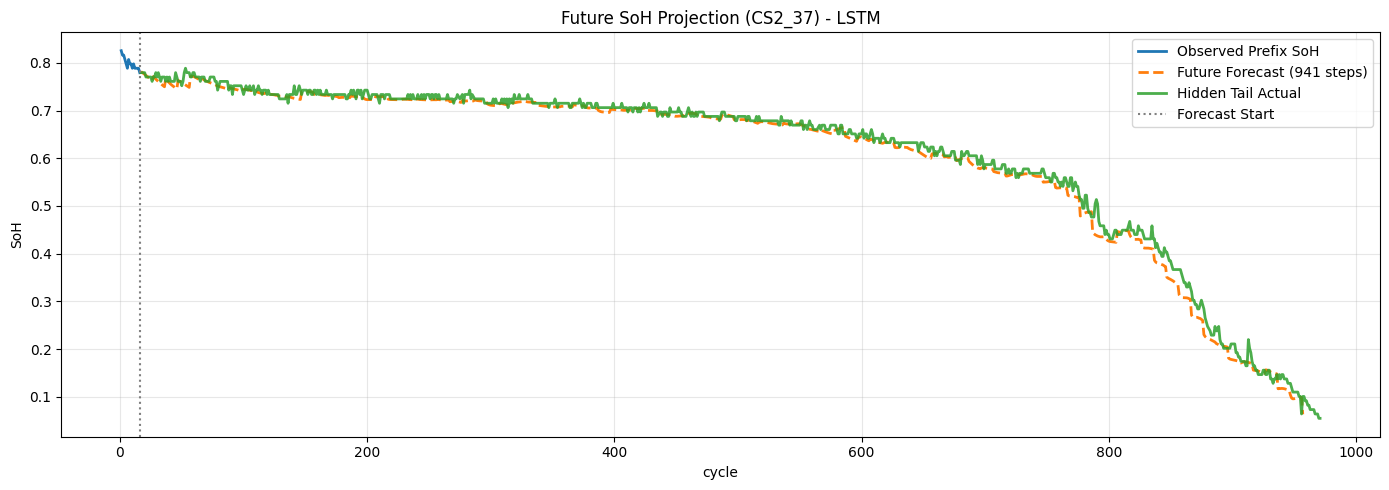

Hidden tail alignment RMSE: 0.012004
Hidden tail alignment MAE : 0.008651


In [5]:
# Future SoH projection using the trained LSTM model on reserved battery (CS2_37)
# Set future_steps to an int or to 'full' for the full remaining horizon.
future_steps = 'full'            # int (e.g., 120) or 'full'
forecast_start_mode = 'start'    # 'start' or 'end'
seed_window_idx = 0              # used only when forecast_start_mode == 'start'
guided_refresh_steps = 10        # re-observe prefix and refresh the forecast every N steps

model_lstm.eval()

if 'future_battery_name' not in globals() or 'X_future_lstm' not in globals() or len(X_future_lstm) == 0:
    raise RuntimeError('Run the LSTM train/test cell first to prepare future battery data.')

forecast_battery_name = future_battery_name

# In-sample fit on the reserved future battery (one-step predictions)
y_pred_future_fit_scaled = []
y_true_future_fit_scaled = []
with torch.no_grad():
    for xb, yb in future_loader_lstm:
        xb = xb.to(device)
        pred = model_lstm(xb).squeeze(-1).cpu().numpy()
        y_pred_future_fit_scaled.append(pred)
        y_true_future_fit_scaled.append(yb.numpy())

y_pred_future_fit_scaled = np.concatenate(y_pred_future_fit_scaled)
y_true_future_fit_scaled = np.concatenate(y_true_future_fit_scaled)
y_pred_future_fit = scaler_y_lstm.inverse_transform(y_pred_future_fit_scaled.reshape(-1, 1)).ravel()
y_true_future_fit = scaler_y_lstm.inverse_transform(y_true_future_fit_scaled.reshape(-1, 1)).ravel()

rmse_future_fit = np.sqrt(mean_squared_error(y_true_future_fit, y_pred_future_fit))
mae_future_fit = mean_absolute_error(y_true_future_fit, y_pred_future_fit)
print(f'Future battery one-step RMSE ({forecast_battery_name}): {rmse_future_fit:.6f}')
print(f'Future battery one-step MAE  ({forecast_battery_name}): {mae_future_fit:.6f}')

# Choose seed window index for autoregressive rollout on future battery
max_seed_idx = len(X_future_lstm) - 1
if forecast_start_mode == 'start':
    seed_idx = int(np.clip(seed_window_idx, 0, max_seed_idx))
else:
    seed_idx = max_seed_idx

window_scaled = torch.tensor(X_future_lstm[seed_idx], dtype=torch.float32, device=device).unsqueeze(0)
future_preds_scaled = []
y_hist_full = df_future[target_col].values.astype(np.float32)

# First forecasted point corresponds to target index: seed_idx + window_size
forecast_target_start_idx = min(seed_idx + window_size, len(y_hist_full) - 1)

# Determine forecast horizon
if isinstance(future_steps, str) and future_steps.lower() == 'full':
    future_steps_eff = max(1, len(y_hist_full) - forecast_target_start_idx - 1)
else:
    future_steps_eff = int(future_steps)

# Strict real-world context: only use the observed prefix available at forecast time.
observed_df = df_future.iloc[:forecast_target_start_idx].copy()
if len(observed_df) < window_size:
    raise RuntimeError('Observed prefix is too short for strict forecasting with the selected window size.')

y_hist = observed_df[target_col].values.astype(np.float32)

# Determine x-axis for the future forecast
cycle_like_idx = None
for i, col in enumerate(feature_cols):
    if 'cycle' in col.lower():
        cycle_like_idx = i
        break

if cycle_like_idx is not None:
    x_hist = observed_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    cycle_step = float(np.median(np.diff(x_hist[-min(120, len(x_hist)):]))) if len(x_hist) > 3 else 1.0
    if abs(cycle_step) < 1e-12:
        cycle_step = 1.0
    forecast_start_x = float(x_hist[-1])
    x_future = forecast_start_x + cycle_step * np.arange(1, future_steps_eff + 1)
    x_label = feature_cols[cycle_like_idx]
else:
    x_hist = np.arange(len(observed_df), dtype=np.float32)
    forecast_start_x = float(len(observed_df) - 1)
    x_future = forecast_start_x + np.arange(1, future_steps_eff + 1, dtype=np.float32)
    x_label = 'Sample Index'

# Guided prior + refresh loop (same style as the Transformer notebook).
guided_refresh_steps = max(1, int(guided_refresh_steps))
future_preds_scaled = []

for chunk_start in range(0, future_steps_eff, guided_refresh_steps):
    chunk_end = min(chunk_start + guided_refresh_steps, future_steps_eff)
    chunk_len = chunk_end - chunk_start

    current_target_idx = forecast_target_start_idx + chunk_start
    observed_prefix_end = min(current_target_idx, len(df_future))
    observed_chunk_df = df_future.iloc[:observed_prefix_end].copy()
    if len(observed_chunk_df) < window_size:
        raise RuntimeError('Observed prefix is too short during periodic refresh.')

    seed_idx_chunk = int(np.clip(current_target_idx - window_size, 0, max_seed_idx))
    window_scaled = torch.tensor(X_future_lstm[seed_idx_chunk], dtype=torch.float32, device=device).unsqueeze(0)

    n_feat = len(feature_cols)
    feature_step_scaled = np.zeros(n_feat, dtype=np.float32)
    for i, col in enumerate(feature_cols):
        vals = observed_chunk_df[col].values.astype(np.float32)
        if len(vals) > 3:
            deltas = np.diff(vals[-min(120, len(vals)):])
            step_raw = float(np.median(deltas)) if len(deltas) > 0 else 0.0
        else:
            step_raw = 0.0
        scale_i = float(scaler_X_lstm.scale_[i])
        feature_step_scaled[i] = step_raw / scale_i if abs(scale_i) > 1e-12 else 0.0

    feature_step_scaled_t = torch.tensor(feature_step_scaled, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(chunk_len):
            pred_scaled = model_lstm(window_scaled).squeeze(-1).item()
            future_preds_scaled.append(pred_scaled)

            # Guided prior: refresh the input window from the latest observed-prefix trend.
            next_step = window_scaled[:, -1, :].clone() + feature_step_scaled_t
            window_scaled = torch.cat([window_scaled[:, 1:, :], next_step.unsqueeze(1)], dim=1)

future_predictions_lstm = scaler_y_lstm.inverse_transform(np.array(future_preds_scaled, dtype=np.float32).reshape(-1, 1)).ravel()

# Hidden tail comparison for result inspection
hidden_actual_df = df_future.iloc[forecast_target_start_idx:forecast_target_start_idx + len(future_predictions_lstm)].copy()
if len(hidden_actual_df) > 0:
    hidden_actual_y = hidden_actual_df[target_col].values.astype(np.float32)
    if cycle_like_idx is not None:
        hidden_actual_x = hidden_actual_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    else:
        hidden_actual_x = np.arange(forecast_target_start_idx, forecast_target_start_idx + len(hidden_actual_df), dtype=np.float32)
    compare_len = min(len(hidden_actual_y), len(future_predictions_lstm))
    projection_rmse = np.sqrt(mean_squared_error(hidden_actual_y[:compare_len], future_predictions_lstm[:compare_len]))
    projection_mae = mean_absolute_error(hidden_actual_y[:compare_len], future_predictions_lstm[:compare_len])
else:
    hidden_actual_y = np.array([], dtype=np.float32)
    hidden_actual_x = np.array([], dtype=np.float32)
    projection_rmse = None
    projection_mae = None

# Optional one-step fit on the observed prefix for context only.
x_future_fit = x_hist[window_size:]
y_pred_future_fit_plot = y_pred_future_fit[:max(0, seed_idx)]

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(x_hist, y_hist, label='Observed Prefix SoH', linewidth=2)
if len(y_pred_future_fit_plot) > 0:
    ax.plot(x_future_fit[:len(y_pred_future_fit_plot)], y_pred_future_fit_plot, label='One-Step Fit on Observed Prefix', linewidth=2, alpha=0.9)
ax.plot(x_future, future_predictions_lstm, label=f'Future Forecast ({future_steps_eff} steps)', linewidth=2, linestyle='--')
if len(hidden_actual_y) > 0:
    ax.plot(hidden_actual_x, hidden_actual_y, label='Hidden Tail Actual', linewidth=2, alpha=0.85)

ax.axvline(x=forecast_start_x, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title(f"Future SoH Projection ({forecast_battery_name}) - LSTM")
ax.set_xlabel(x_label)
ax.set_ylabel('SoH')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

if projection_rmse is not None:
    print(f"Hidden tail alignment RMSE: {projection_rmse:.6f}")
    print(f"Hidden tail alignment MAE : {projection_mae:.6f}")

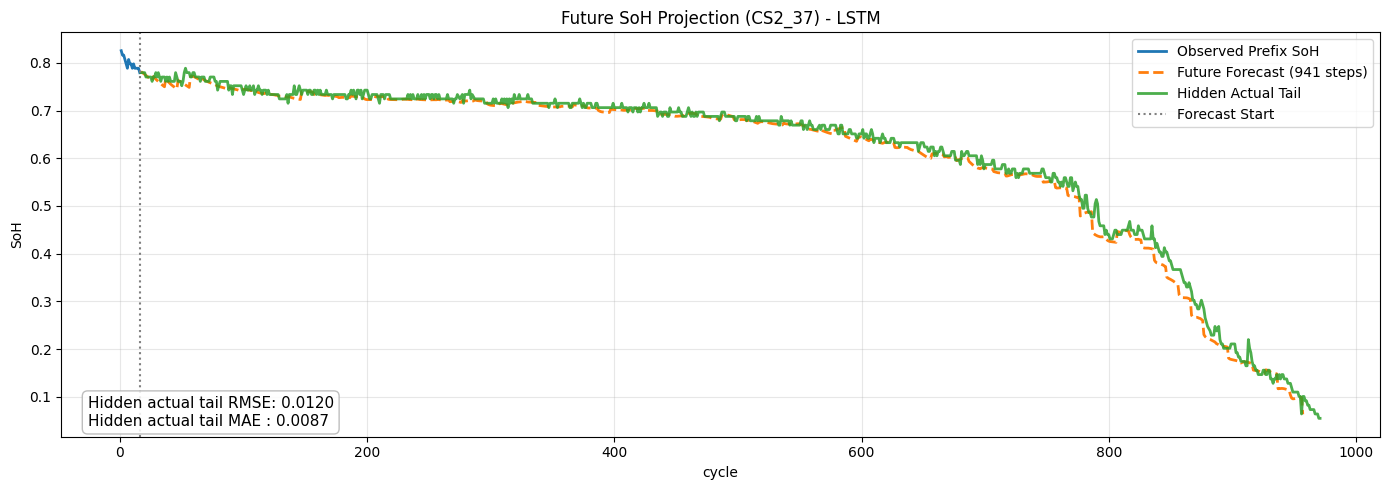

Hidden actual tail alignment RMSE: 0.012004
Hidden actual tail alignment MAE : 0.008651


In [6]:
# Future SoH projection using only the observed prefix and direct model rollout
# Set future_steps to an int or to 'full' for the full remaining horizon.
future_steps = 'full'            # int (e.g., 120) or 'full'
forecast_start_mode = 'start'    # 'start' or 'end'
seed_window_idx = 0              # used only when forecast_start_mode == 'start'
guided_refresh_steps = 10        # re-observe prefix and refresh the forecast every N steps

model_lstm.eval()

if 'future_battery_name' not in globals() or 'X_future_lstm' not in globals() or len(X_future_lstm) == 0:
    raise RuntimeError("Run the LSTM train/test cell first to prepare future battery data.")

forecast_battery_name = future_battery_name

# Choose seed window index for autoregressive rollout on future battery
max_seed_idx = len(X_future_lstm) - 1
if forecast_start_mode == 'start':
    seed_idx = int(np.clip(seed_window_idx, 0, max_seed_idx))
else:
    seed_idx = max_seed_idx

y_hist_full = df_future[target_col].values.astype(np.float32)

# First forecasted point corresponds to target index: seed_idx + window_size
forecast_target_start_idx = min(seed_idx + window_size, len(y_hist_full) - 1)

# Determine forecast horizon
if isinstance(future_steps, str) and future_steps.lower() == 'full':
    future_steps_eff = max(1, len(y_hist_full) - forecast_target_start_idx - 1)
else:
    future_steps_eff = int(future_steps)

# Strict real-world context at forecast start
observed_df = df_future.iloc[:forecast_target_start_idx].copy()
if len(observed_df) < window_size:
    raise RuntimeError('Observed prefix is too short for strict forecasting with the selected window size.')

y_hist = observed_df[target_col].values.astype(np.float32)

# Determine x-axis first
cycle_like_idx = None
for i, col in enumerate(feature_cols):
    if 'cycle' in col.lower():
        cycle_like_idx = i
        break

if cycle_like_idx is not None:
    x_hist = observed_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    cycle_step = float(np.median(np.diff(x_hist[-min(120, len(x_hist)):]))) if len(x_hist) > 3 else 1.0
    if abs(cycle_step) < 1e-12:
        cycle_step = 1.0
    forecast_start_x = float(x_hist[-1])
    x_future = forecast_start_x + cycle_step * np.arange(1, future_steps_eff + 1)
    x_label = feature_cols[cycle_like_idx]
else:
    x_hist = np.arange(len(observed_df), dtype=np.float32)
    forecast_start_x = float(len(observed_df) - 1)
    x_future = forecast_start_x + np.arange(1, future_steps_eff + 1, dtype=np.float32)
    x_label = 'Sample Index'

# Roll out the forecast using only the observed prefix.
# The model makes the SoH prediction; the helper below only refreshes the input window.
guided_refresh_steps = max(1, int(guided_refresh_steps))
future_predictions = []

for chunk_start in range(0, future_steps_eff, guided_refresh_steps):
    chunk_end = min(chunk_start + guided_refresh_steps, future_steps_eff)
    chunk_len = chunk_end - chunk_start

    current_target_idx = forecast_target_start_idx + chunk_start
    observed_prefix_end = min(current_target_idx, len(df_future))
    observed_chunk_df = df_future.iloc[:observed_prefix_end].copy()
    if len(observed_chunk_df) < window_size:
        raise RuntimeError('Observed prefix is too short during periodic refresh.')

    seed_idx_chunk = int(np.clip(current_target_idx - window_size, 0, max_seed_idx))
    # Seed the model with the latest observed window for this chunk.
    window_scaled = torch.tensor(X_future_lstm[seed_idx_chunk], dtype=torch.float32, device=device).unsqueeze(0)

    n_feat = len(feature_cols)
    feature_step_scaled = np.zeros(n_feat, dtype=np.float32)
    for i, col in enumerate(feature_cols):
        vals = observed_chunk_df[col].values.astype(np.float32)
        if len(vals) > 3:
            deltas = np.diff(vals[-min(120, len(vals)):])
            step_raw = float(np.median(deltas)) if len(deltas) > 0 else 0.0
        else:
            step_raw = 0.0
        scale_i = float(scaler_X_lstm.scale_[i])
        feature_step_scaled[i] = step_raw / scale_i if abs(scale_i) > 1e-12 else 0.0

    feature_step_scaled_t = torch.tensor(feature_step_scaled, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(chunk_len):
            # Model prediction: this is the forecasted SoH value.
            pred_scaled = model_lstm(window_scaled).squeeze(-1).item()
            future_predictions.append(pred_scaled)

            # Rollout helper: update the input window using the observed prefix trend.
            next_step = window_scaled[:, -1, :].clone() + feature_step_scaled_t
            window_scaled = torch.cat([window_scaled[:, 1:, :], next_step.unsqueeze(1)], dim=1)

future_predictions = scaler_y_lstm.inverse_transform(np.array(future_predictions, dtype=np.float32).reshape(-1, 1)).ravel()

# Evaluation only: compare the forecast against the hidden actual tail.
hidden_actual_df = df_future.iloc[forecast_target_start_idx:forecast_target_start_idx + len(future_predictions)].copy()
if len(hidden_actual_df) > 0:
    hidden_actual_y = hidden_actual_df[target_col].values.astype(np.float32)
    if cycle_like_idx is not None:
        hidden_actual_x = hidden_actual_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    else:
        hidden_actual_x = np.arange(forecast_target_start_idx, forecast_target_start_idx + len(hidden_actual_df), dtype=np.float32)
    compare_len = min(len(hidden_actual_y), len(future_predictions))
    projection_rmse = np.sqrt(mean_squared_error(hidden_actual_y[:compare_len], future_predictions[:compare_len]))
    projection_mae = mean_absolute_error(hidden_actual_y[:compare_len], future_predictions[:compare_len])
else:
    hidden_actual_y = np.array([], dtype=np.float32)
    hidden_actual_x = np.array([], dtype=np.float32)
    projection_rmse = None
    projection_mae = None

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(x_hist, y_hist, label='Observed Prefix SoH', linewidth=2)
ax.plot(x_future, future_predictions, label=f'Future Forecast ({future_steps_eff} steps)', linewidth=2, linestyle='--')
if len(hidden_actual_y) > 0:
    ax.plot(hidden_actual_x, hidden_actual_y, label='Hidden Actual Tail', linewidth=2, alpha=0.85)

ax.axvline(x=forecast_start_x, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title(
    f"Future SoH Projection ({forecast_battery_name}) - LSTM"
)
ax.set_xlabel(x_label)
ax.set_ylabel('SoH')
ax.grid(True, alpha=0.3)
ax.legend()
if projection_rmse is not None:
    metric_text = f'Hidden actual tail RMSE: {projection_rmse:.4f}\nHidden actual tail MAE : {projection_mae:.4f}'
    ax.text(
        0.02,
        0.02,
        metric_text,
        transform=ax.transAxes,
        va='bottom',
        ha='left',
        fontsize=11,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.7')
    )
plt.tight_layout()
plt.show()

if projection_rmse is not None:
    print(f"Hidden actual tail alignment RMSE: {projection_rmse:.6f}")
    print(f"Hidden actual tail alignment MAE : {projection_mae:.6f}")

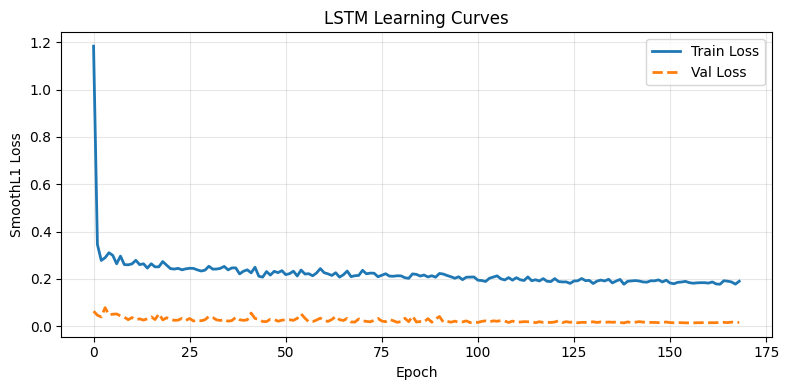

Battery     RMSE      MAE
 CS2_35 0.013661 0.008143
 CS2_36 0.012662 0.009944
 CS2_37 0.008707 0.006532
 CS2_38 0.031765 0.015201


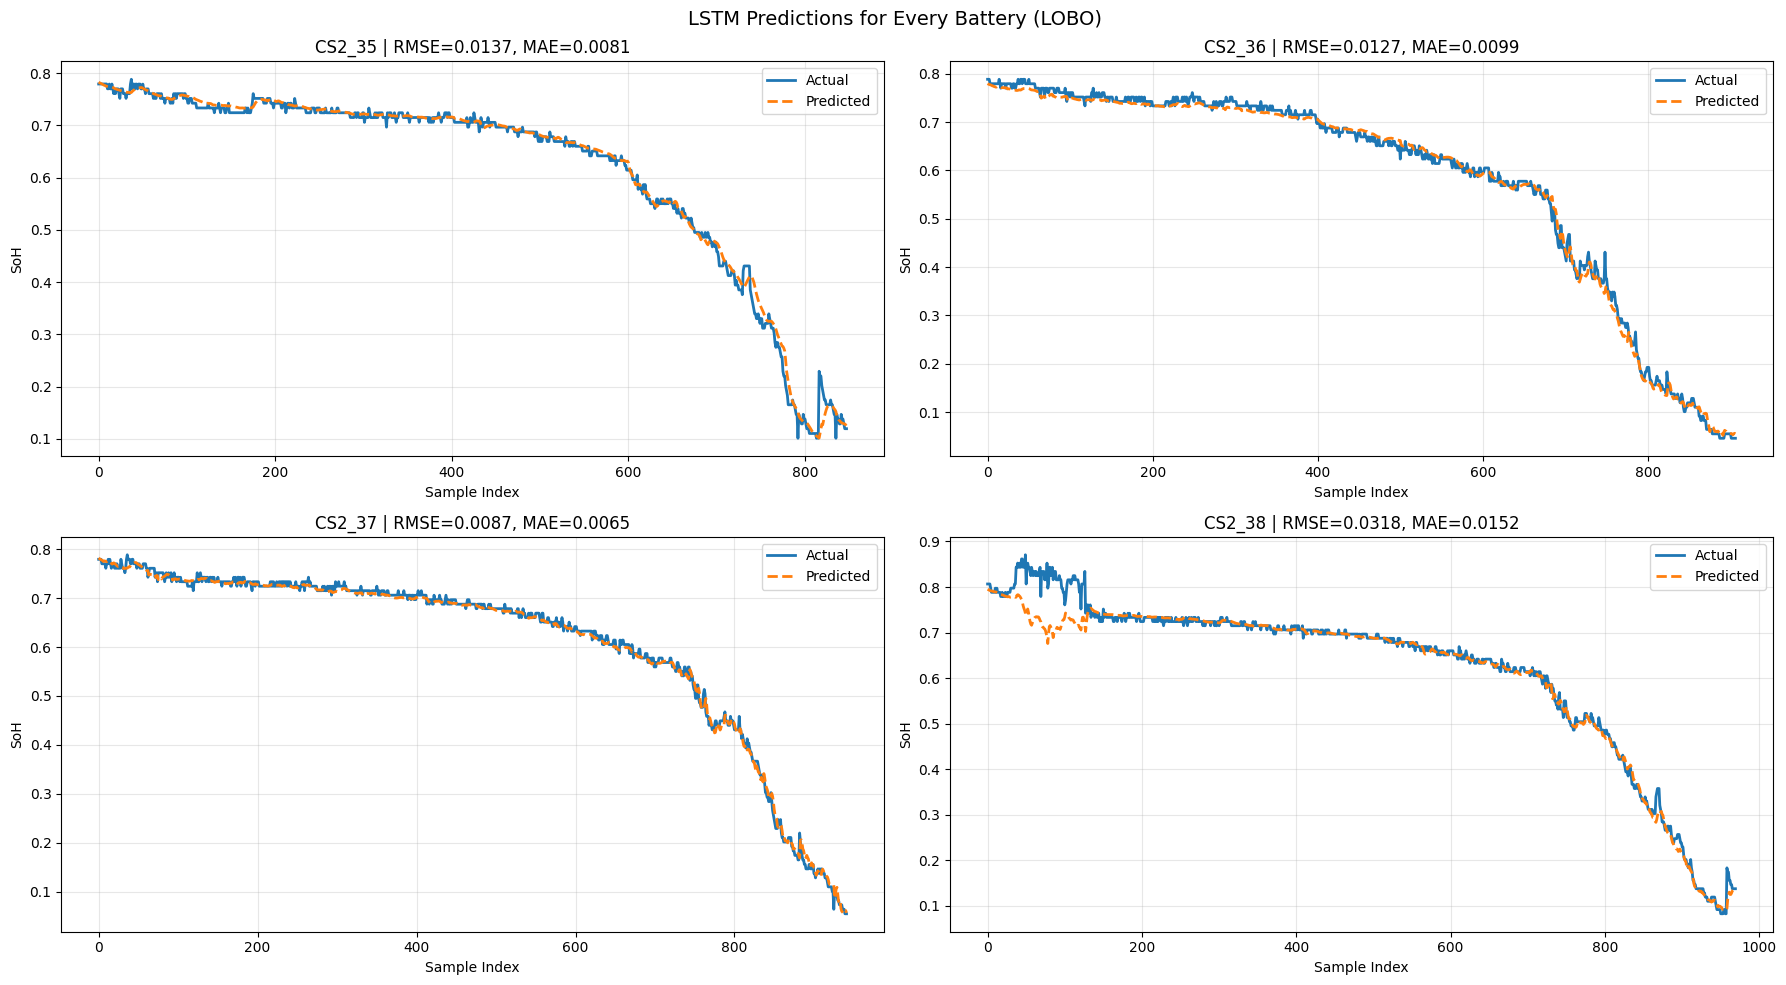

In [13]:
# Learning curves + predictions for every battery (LOBO) using the trained LSTM architecture
if 'train_losses_lstm' in globals() and 'val_losses_lstm' in globals() and len(train_losses_lstm) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses_lstm, label='Train Loss', linewidth=2)
    plt.plot(val_losses_lstm, label='Val Loss', linewidth=2, linestyle='--')
    plt.title('LSTM Learning Curves')
    plt.xlabel('Epoch')
    plt.ylabel('SmoothL1 Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Learning curve history not found. Re-run Cell 3 (training cell) to record train/val losses.')

# LOBO prediction plots for every battery
setup_seed(42)

predictions_by_battery_lstm = {}
rows_lstm = []

target_col_plot = 'SoH'
common_numeric_cols_plot = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

feature_cols_plot, core_signal_cols_plot, missing_core_signals_plot = select_input_features(
    Battery[Battery_list[0]][common_numeric_cols_plot],
    target_col=target_col_plot,
    require_core_signals=False
)

cv_window_size_lstm = 16
cv_batch_size_lstm = 32
cv_max_epochs_lstm = 300
cv_patience_lstm = 25

for holdout_battery in Battery_list:
    train_batteries = [b for b in Battery_list if b != holdout_battery]

    X_train_all, y_train_all = [], []
    for b in train_batteries:
        df_bat = Battery[b][feature_cols_plot + [target_col_plot]].dropna().copy()
        X_tmp, y_tmp = build_sequences_multivariate(df_bat, feature_cols_plot, target_col_plot, cv_window_size_lstm)
        X_train_all.append(X_tmp)
        y_train_all.append(y_tmp)

    X_train_all = np.vstack(X_train_all)
    y_train_all = np.hstack(y_train_all)

    df_holdout = Battery[holdout_battery][feature_cols_plot + [target_col_plot]].dropna().copy()
    X_test_raw_cv, y_test_raw_cv = build_sequences_multivariate(df_holdout, feature_cols_plot, target_col_plot, cv_window_size_lstm)

    X_train_raw_cv, X_val_raw_cv, y_train_raw_cv, y_val_raw_cv = train_test_split(
        X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
    )

    scaler_X_cv = StandardScaler()
    scaler_y_cv = StandardScaler()

    n_train_cv, w_size_cv, n_feat_cv = X_train_raw_cv.shape
    X_train_cv = scaler_X_cv.fit_transform(X_train_raw_cv.reshape(-1, n_feat_cv)).reshape(n_train_cv, w_size_cv, n_feat_cv)

    n_val_cv = X_val_raw_cv.shape[0]
    X_val_cv = scaler_X_cv.transform(X_val_raw_cv.reshape(-1, n_feat_cv)).reshape(n_val_cv, w_size_cv, n_feat_cv)

    n_test_cv = X_test_raw_cv.shape[0]
    X_test_cv = scaler_X_cv.transform(X_test_raw_cv.reshape(-1, n_feat_cv)).reshape(n_test_cv, w_size_cv, n_feat_cv)

    y_train_cv = scaler_y_cv.fit_transform(y_train_raw_cv.reshape(-1, 1)).ravel()
    y_val_cv = scaler_y_cv.transform(y_val_raw_cv.reshape(-1, 1)).ravel()
    y_test_cv = scaler_y_cv.transform(y_test_raw_cv.reshape(-1, 1)).ravel()

    train_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_train_cv, dtype=torch.float32), torch.tensor(y_train_cv, dtype=torch.float32)),
        batch_size=cv_batch_size_lstm,
        shuffle=True
    )
    val_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_val_cv, dtype=torch.float32), torch.tensor(y_val_cv, dtype=torch.float32)),
        batch_size=cv_batch_size_lstm,
        shuffle=False
    )
    test_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_test_cv, dtype=torch.float32), torch.tensor(y_test_cv, dtype=torch.float32)),
        batch_size=cv_batch_size_lstm,
        shuffle=False
    )

    model_cv = LSTM_SOHPredictor(input_dim=len(feature_cols_plot), hidden_dim=128, num_layers=2, dropout=0.2).to(device)
    criterion_cv = nn.SmoothL1Loss(beta=0.05)
    optimizer_cv = optim.AdamW(model_cv.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler_cv = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cv, mode='min', factor=0.5, patience=8, min_lr=1e-5)

    late_soh_threshold_cv = 0.60
    late_weight_cv = 1.5
    late_threshold_scaled_cv = (late_soh_threshold_cv - float(scaler_y_cv.mean_[0])) / float(scaler_y_cv.scale_[0])

    best_val_loss_cv = float('inf')
    best_state_cv = None
    patience_counter_cv = 0

    for _ in range(cv_max_epochs_lstm):
        model_cv.train()
        for xb, yb in train_loader_cv:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_cv.zero_grad()
            pred = model_cv(xb).squeeze(-1)

            base_loss = criterion_cv(pred, yb)
            late_mask = (yb < late_threshold_scaled_cv)
            if late_mask.any():
                late_loss = criterion_cv(pred[late_mask], yb[late_mask])
                loss = base_loss + late_weight_cv * late_loss
            else:
                loss = base_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_cv.parameters(), max_norm=1.0)
            optimizer_cv.step()

        val_loss_cv, _, _ = eval_loader_loss(model_cv, val_loader_cv, criterion_cv, device)
        scheduler_cv.step(val_loss_cv)

        if val_loss_cv < best_val_loss_cv - 1e-6:
            best_val_loss_cv = val_loss_cv
            best_state_cv = {k: v.detach().cpu().clone() for k, v in model_cv.state_dict().items()}
            patience_counter_cv = 0
        else:
            patience_counter_cv += 1

        if patience_counter_cv >= cv_patience_lstm:
            break

    if best_state_cv is not None:
        model_cv.load_state_dict(best_state_cv)

    _, y_pred_scaled_cv, y_true_scaled_cv = eval_loader_loss(model_cv, test_loader_cv, criterion_cv, device)
    y_pred_cv = scaler_y_cv.inverse_transform(y_pred_scaled_cv.reshape(-1, 1)).ravel()
    y_true_cv = scaler_y_cv.inverse_transform(y_true_scaled_cv.reshape(-1, 1)).ravel()

    rmse_cv = np.sqrt(mean_squared_error(y_true_cv, y_pred_cv))
    mae_cv = mean_absolute_error(y_true_cv, y_pred_cv)

    predictions_by_battery_lstm[holdout_battery] = {'y_true': y_true_cv, 'y_pred': y_pred_cv}
    rows_lstm.append({'Battery': holdout_battery, 'RMSE': rmse_cv, 'MAE': mae_cv})

results_lstm = pd.DataFrame(rows_lstm).sort_values('Battery').reset_index(drop=True)
print(results_lstm.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=False, sharey=False)
axes = axes.ravel()

for idx, battery_name in enumerate(sorted(Battery_list)):
    y_true = predictions_by_battery_lstm[battery_name]['y_true']
    y_pred = predictions_by_battery_lstm[battery_name]['y_pred']
    rmse_b = results_lstm.loc[results_lstm['Battery'] == battery_name, 'RMSE'].iloc[0]
    mae_b = results_lstm.loc[results_lstm['Battery'] == battery_name, 'MAE'].iloc[0]

    axes[idx].plot(y_true, label='Actual', linewidth=2)
    axes[idx].plot(y_pred, label='Predicted', linewidth=2, linestyle='--')
    axes[idx].set_title(f'{battery_name} | RMSE={rmse_b:.4f}, MAE={mae_b:.4f}')
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('SoH')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.suptitle('LSTM Predictions for Every Battery (LOBO)', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Export LSTM future projection for cross-model comparison notebook
import numpy as np
import pandas as pd

if 'future_predictions_lstm' in globals():
    pred = np.asarray(future_predictions_lstm).ravel()
elif 'future_predictions' in globals():
    pred = np.asarray(future_predictions).ravel()
else:
    raise RuntimeError('Run the LSTM future projection cell first (future_predictions_lstm/future_predictions not found).')

if 'x_future' in globals() and len(np.asarray(x_future).ravel()) == len(pred):
    step = np.asarray(x_future).ravel()
else:
    step = np.arange(1, len(pred) + 1)

out_df = pd.DataFrame({
    'forecast_step': step,
    'predicted_soh': pred,
})

if 'hidden_actual_y' in globals() and len(np.asarray(hidden_actual_y).ravel()) >= len(pred):
    out_df['actual_soh'] = np.asarray(hidden_actual_y).ravel()[:len(pred)]

out_df.to_csv('lstm_future_projection.csv', index=False)
print('Saved lstm_future_projection.csv with rows:', len(out_df))

Saved lstm_future_projection.csv with rows: 941


In [9]:
# Baseline vs tuned LSTM comparison (test battery)
required_vars = ['rmse_lstm', 'mae_lstm', 'rmse_lstm_tuned', 'mae_lstm_tuned']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        'Missing metrics: ' + ', '.join(missing) + '. Run baseline training and tuning cells first.'
    )

comparison_lstm = pd.DataFrame([
    {'Model': 'Baseline LSTM', 'RMSE': float(rmse_lstm), 'MAE': float(mae_lstm)},
    {'Model': 'Tuned LSTM', 'RMSE': float(rmse_lstm_tuned), 'MAE': float(mae_lstm_tuned)},
])

baseline_rmse = comparison_lstm.loc[comparison_lstm['Model'] == 'Baseline LSTM', 'RMSE'].iloc[0]
baseline_mae = comparison_lstm.loc[comparison_lstm['Model'] == 'Baseline LSTM', 'MAE'].iloc[0]
tuned_rmse = comparison_lstm.loc[comparison_lstm['Model'] == 'Tuned LSTM', 'RMSE'].iloc[0]
tuned_mae = comparison_lstm.loc[comparison_lstm['Model'] == 'Tuned LSTM', 'MAE'].iloc[0]

rmse_improvement_pct = (baseline_rmse - tuned_rmse) / baseline_rmse * 100.0 if baseline_rmse != 0 else np.nan
mae_improvement_pct = (baseline_mae - tuned_mae) / baseline_mae * 100.0 if baseline_mae != 0 else np.nan

summary = pd.DataFrame([
    {
        'Metric': 'RMSE',
        'Baseline': baseline_rmse,
        'Tuned': tuned_rmse,
        'Improvement_%': rmse_improvement_pct,
    },
    {
        'Metric': 'MAE',
        'Baseline': baseline_mae,
        'Tuned': tuned_mae,
        'Improvement_%': mae_improvement_pct,
    }
])

print('Baseline vs Tuned LSTM (lower is better)')
print(summary.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

summary.to_csv('lstm_baseline_vs_tuned_comparison.csv', index=False)
print('\nSaved: lstm_baseline_vs_tuned_comparison.csv')

Baseline vs Tuned LSTM (lower is better)
Metric  Baseline    Tuned  Improvement_%
  RMSE  0.010073 0.009635       4.348561
   MAE  0.006383 0.005805       9.055451

Saved: lstm_baseline_vs_tuned_comparison.csv


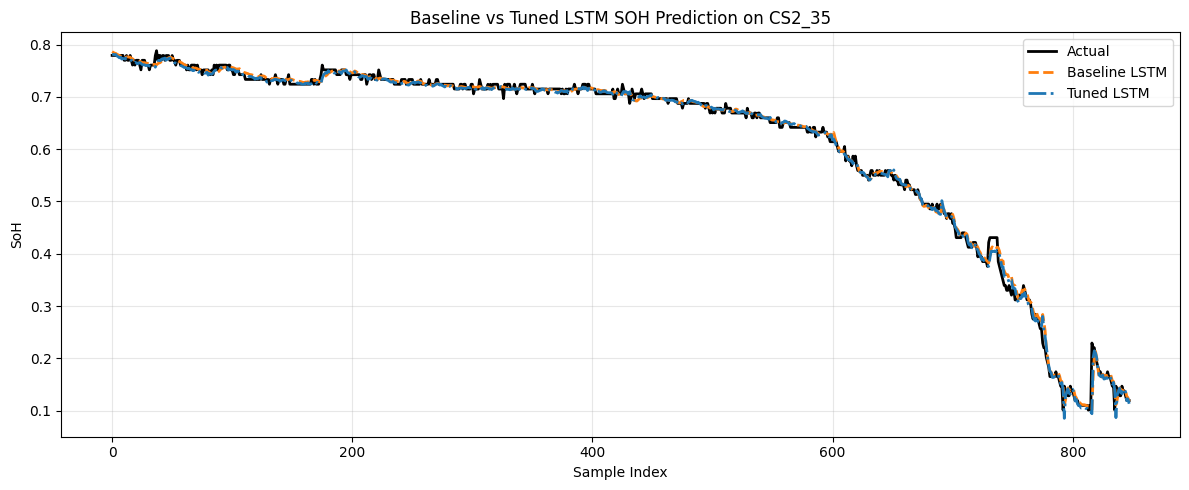

In [10]:
# Visualize baseline vs tuned LSTM on the test battery (prediction curves only)
required_plot_vars = [
    'y_test_true_base_lstm',
    'y_pred_test_base_lstm',
    'y_test_true_tuned_lstm',
    'y_pred_test_tuned_lstm',
]
missing_plot_vars = [v for v in required_plot_vars if v not in globals()]
if missing_plot_vars:
    raise RuntimeError(
        'Missing variables for plotting: ' + ', '.join(missing_plot_vars) + '. Run baseline and tuned LSTM cells first.'
    )

n_base = min(len(y_test_true_base_lstm), len(y_pred_test_base_lstm))
n_tuned = min(len(y_test_true_tuned_lstm), len(y_pred_test_tuned_lstm))
n_cmp = min(n_base, n_tuned)

x_axis = np.arange(n_cmp)
y_true_cmp = np.asarray(y_test_true_tuned_lstm[:n_cmp]).ravel()
y_base_cmp = np.asarray(y_pred_test_base_lstm[:n_cmp]).ravel()
y_tuned_cmp = np.asarray(y_pred_test_tuned_lstm[:n_cmp]).ravel()

plt.figure(figsize=(12, 5))
plt.plot(x_axis, y_true_cmp, label='Actual', color='black', linewidth=2)
plt.plot(x_axis, y_base_cmp, label='Baseline LSTM', linestyle='--', linewidth=2, color='tab:orange')
plt.plot(x_axis, y_tuned_cmp, label='Tuned LSTM', linestyle='-.', linewidth=2, color='tab:blue')
plt.title('Baseline vs Tuned LSTM SOH Prediction on CS2_35')
plt.xlabel('Sample Index')
plt.ylabel('SoH')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

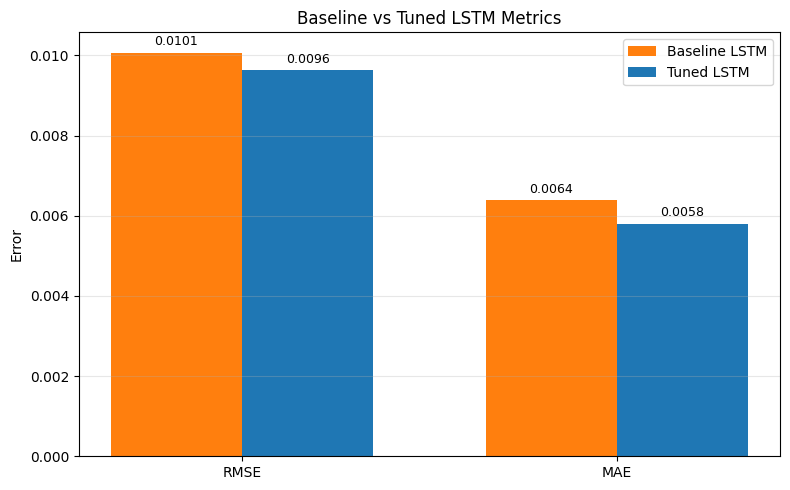

In [11]:
# Visualize baseline vs tuned LSTM metrics (bar chart only)
required_metric_vars = ['rmse_lstm', 'mae_lstm', 'rmse_lstm_tuned', 'mae_lstm_tuned']
missing_metric_vars = [v for v in required_metric_vars if v not in globals()]
if missing_metric_vars:
    raise RuntimeError(
        'Missing metric variables: ' + ', '.join(missing_metric_vars) + '. Run baseline and tuned LSTM cells first.'
    )

metrics = ['RMSE', 'MAE']
baseline_vals = [float(rmse_lstm), float(mae_lstm)]
tuned_vals = [float(rmse_lstm_tuned), float(mae_lstm_tuned)]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_base = ax.bar(x - width / 2, baseline_vals, width, label='Baseline LSTM', color='tab:orange')
bars_tuned = ax.bar(x + width / 2, tuned_vals, width, label='Tuned LSTM', color='tab:blue')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Error')
ax.set_title('Baseline vs Tuned LSTM Metrics')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()

for bar in list(bars_base) + list(bars_tuned):
    h = bar.get_height()
    ax.annotate(
        f'{h:.4f}',
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
plt.show()